In [3]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv("data/Shopping Mall Customer Segmentation Data.csv")
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [5]:
print(df.isnull().sum())
print(df.info())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


In [6]:
df.drop(columns=["CustomerID"],inplace = True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [7]:
scaler = StandardScaler()
if "Gender" in df.columns:
    df = pd.get_dummies(df,columns=["Gender"],drop_first = True)
scaler_matrix = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaler_matrix,columns=df.columns)
df_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


In [8]:
df_feature = df_scaled[["Annual Income (k$)","Spending Score (1-100)"]]
df_feature.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


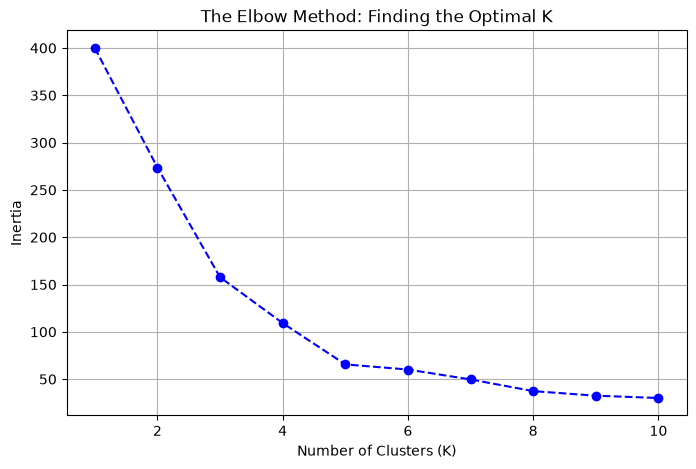

In [9]:
inertia = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i ,random_state = 42 , n_init = "auto")
    kmeans.fit(df_feature)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o', color='blue', linestyle='--')
plt.title('The Elbow Method: Finding the Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

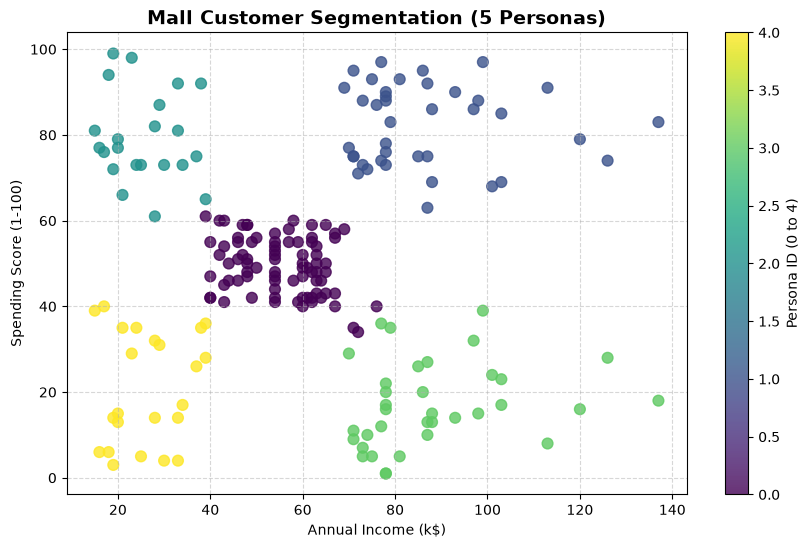

In [10]:
optimal_i = 5
f_kmeans = KMeans(n_clusters = optimal_i,random_state=42,n_init="auto")
cluster_labels = f_kmeans.fit_predict(df_feature)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                      c=cluster_labels, cmap='viridis', s=60, alpha=0.8)
plt.title('Mall Customer Segmentation (5 Personas)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(scatter, label='Persona ID (0 to 4)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()